# 04 Modeling

Notebook này trình bày hai nhánh modeling còn lại của Đề 1: `classification` và `forecasting`.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_params
from src.data import load_raw_data, clean_sales_data
from src.features import build_customer_features, build_sales_time_series
from src.models import run_customer_classification, run_forecasting_experiment

config = load_params()
raw_df = load_raw_data(config, PROJECT_ROOT)
clean_df, cleaning_report = clean_sales_data(raw_df, config)
customer_features = build_customer_features(clean_df)
sales_ts = build_sales_time_series(
    clean_df,
    frequency=config['forecasting']['frequency'],
    target_column=config['forecasting']['target_column'],
)

print('Cleaning report:', cleaning_report)
print('Customer feature shape:', customer_features.shape)
print('Time series shape:', sales_ts.shape)


Cleaning report: {'raw_rows': 9800, 'duplicate_rows_removed': 0, 'invalid_date_rows': 0, 'missing_core_rows': 0, 'final_rows': 9800, 'optional_columns_available': [], 'optional_columns_missing': ['Quantity', 'Discount', 'Profit']}
Customer feature shape: (793, 15)
Time series shape: (48, 9)


In [2]:
classification_comparison_df, classification_predictions_df, classification_confusion_df, classification_class_report_df = run_customer_classification(customer_features, config)
print('Classification comparison')
display(classification_comparison_df)


Classification comparison


,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr,params
0,logistic_regression,0.386935,0.369547,0.396632,0.548107,"{'C': 10.0, 'class_weight': 'balanced'}"
1,decision_tree,0.427136,0.346540,0.407274,0.515597,"{'max_depth': 5, 'min_samples_leaf': 3, 'class..."
2,random_forest,0.432161,0.327754,0.403686,0.491491,"{'n_estimators': 100, 'max_depth': None, 'min_..."


In [3]:
print('Confusion matrix values')
display(classification_confusion_df)
print('Classification by class')
display(classification_class_report_df.head(10))
print('Classification predictions sample')
display(classification_predictions_df.head())


Confusion matrix values


,Consumer,Corporate,Home Office
Consumer,42,30,31
Corporate,20,16,23
Home Office,10,8,19


Classification by class


,label,precision,recall,f1-score,support
0,Consumer,0.583333,0.407767,0.480000,103.000000
1,Corporate,0.296296,0.271186,0.283186,59.000000
2,Home Office,0.260274,0.513514,0.345455,37.000000
3,accuracy,0.386935,0.386935,0.386935,0.386935
4,macro avg,0.379968,0.397489,0.369547,199.000000
5,weighted avg,0.438166,0.386935,0.396632,199.000000


Classification predictions sample


,Customer Key,actual_segment,predicted_segment,correct
0,DC-13285,Consumer,Consumer,True
1,PG-18820,Consumer,Corporate,False
2,BB-11545,Corporate,Consumer,False
3,CM-12235,Consumer,Home Office,False
4,JG-15115,Consumer,Home Office,False


In [4]:
forecast_comparison_df, forecast_predictions_df, forecast_residual_df = run_forecasting_experiment(sales_ts, config)
print('Forecast comparison')
display(forecast_comparison_df)


Forecast comparison


,model,status,MAE,RMSE,sMAPE
0,holt_winters,ok,13133.389642,18419.610063,18.725010
1,sarimax,ok,20260.639786,25542.927647,29.082786
2,naive,ok,31636.566033,37862.673859,45.629744
3,moving_average,ok,36185.879167,42565.872804,54.739688
4,prophet,unavailable: prophet is not installed in the c...,NaN,NaN,NaN


In [5]:
print('Forecast residual sample')
display(forecast_residual_df.head())
print('Forecast prediction sample')
display(forecast_predictions_df.head())


Forecast residual sample


,ds,actual,predicted,residual
0,2018-07-01,44825.1040,45298.381413,-473.277413
1,2018-08-01,62837.8480,45708.873260,17128.974740
2,2018-09-01,86152.8880,86146.948972,5.939028
3,2018-10-01,77448.1312,46306.558474,31141.572726
4,2018-11-01,117938.1550,90248.935821,27689.219179


Forecast prediction sample


,ds,y,naive,moving_average,holt_winters,sarimax,prophet
0,2018-07-01,44825.1040,48190.7277,42519.54,45298.381413,41294.010020,NaN
1,2018-08-01,62837.8480,48190.7277,42519.54,45708.873260,35970.945027,NaN
2,2018-09-01,86152.8880,48190.7277,42519.54,86146.948972,63564.380918,NaN
3,2018-10-01,77448.1312,48190.7277,42519.54,46306.558474,56701.548475,NaN
4,2018-11-01,117938.1550,48190.7277,42519.54,90248.935821,70615.557344,NaN



Classification confusion matrix


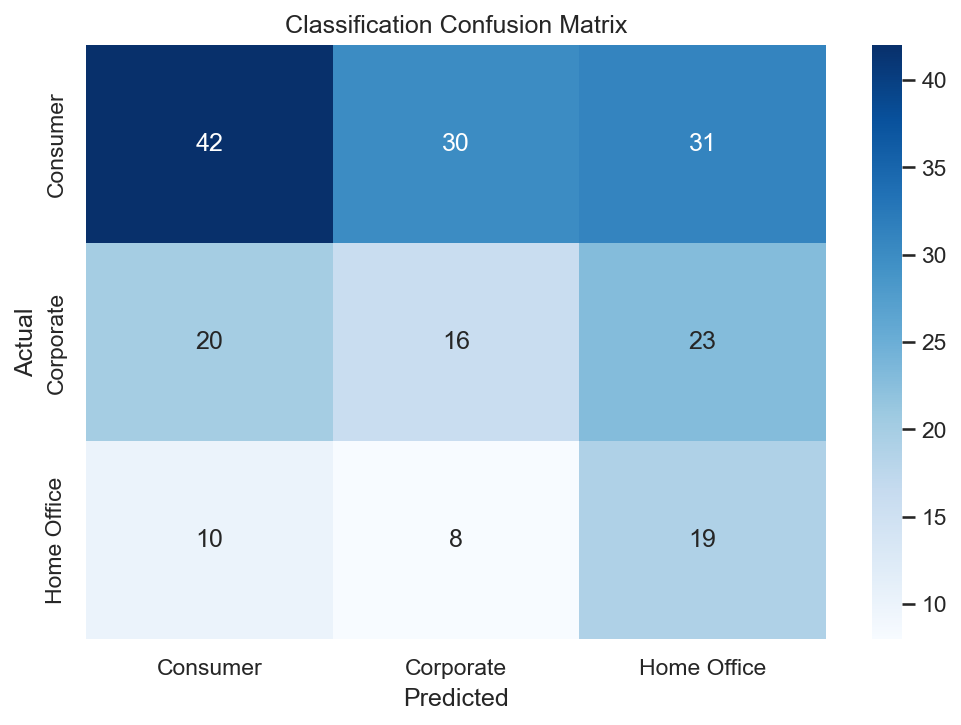


Forecast vs actual


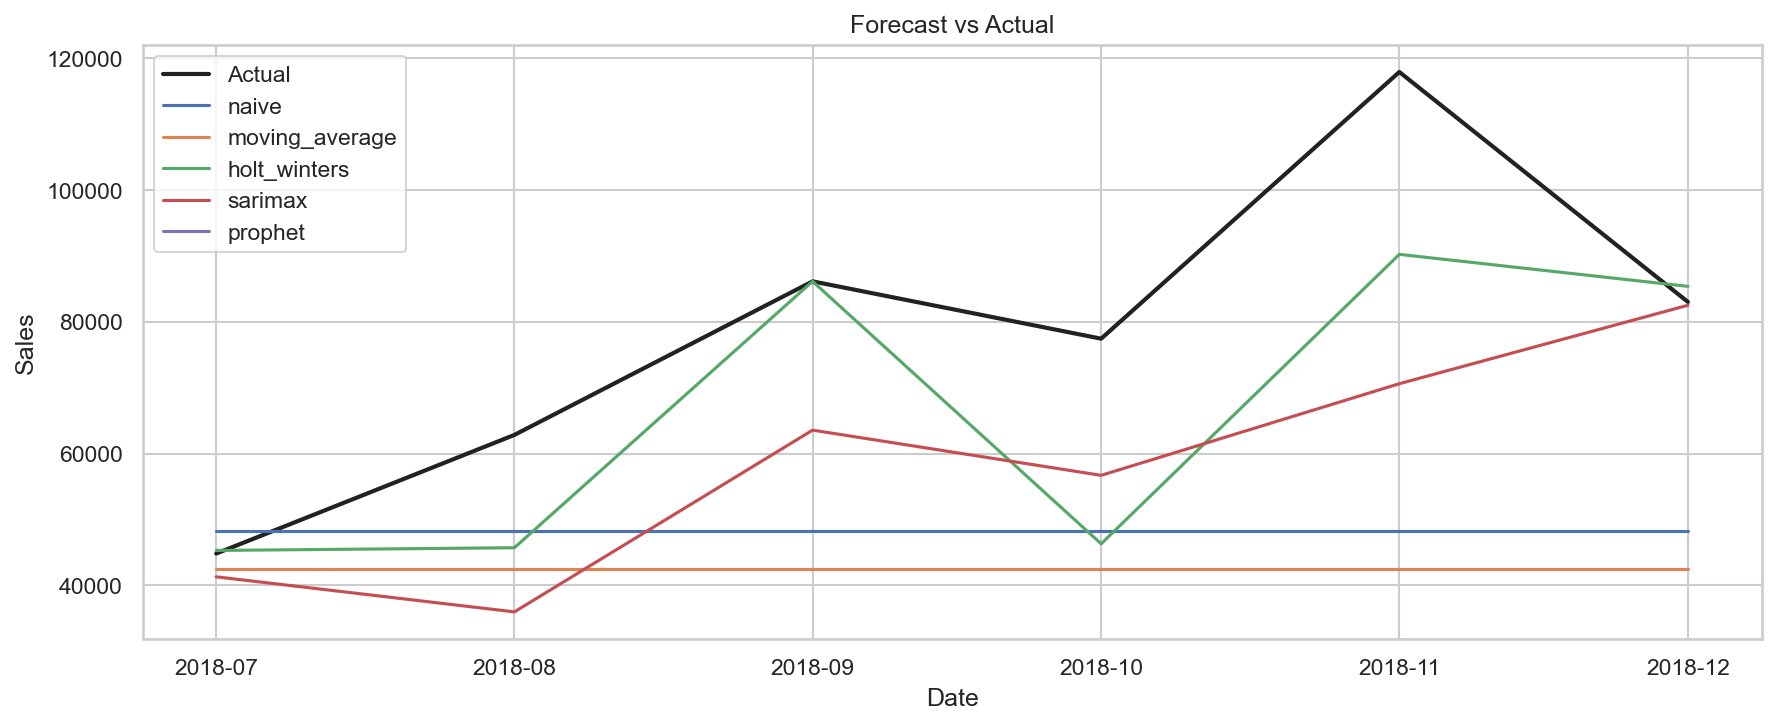


Forecast residuals


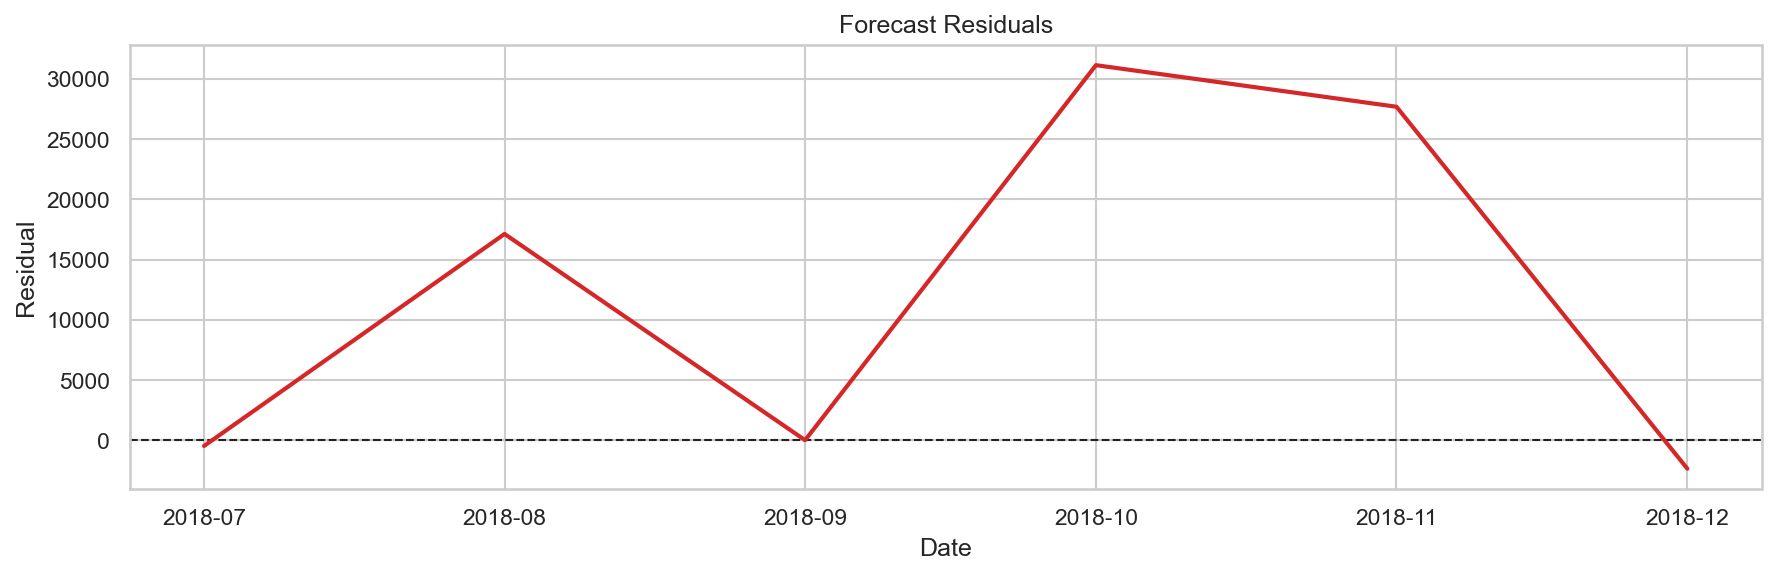

In [6]:
figures_dir = PROJECT_ROOT / 'outputs' / 'figures'
for title, filename in [
    ('Classification confusion matrix', 'classification_confusion_matrix.png'),
    ('Forecast vs actual', 'forecast_vs_actual.png'),
    ('Forecast residuals', 'forecast_residuals.png'),
]:
    path = figures_dir / filename
    print(f'\n{title}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing figure: {path}')
